In [4]:
import ee
import geemap
import numpy as np
import matplotlib.pyplot as plt

ee.Initialize(project='farmland-supervision')
print("GEE 初始化成功")

GEE 初始化成功


In [5]:
# 研究区域：河南省高标准农田区
roi = ee.Geometry.Rectangle([114.0, 34.5, 114.3, 34.8])

# 加载 Sentinel-2，2023年夏季，云量<20%
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(roi)
      .filterDate('2023-06-01', '2023-08-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
      .select(['B4', 'B8']))

print(f"符合条件的图像数量：{s2.size().getInfo()}")

# 计算 NDVI 中位数
ndvi = (s2.map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI'))
          .median()
          .clip(roi))
print("NDVI 计算完成")

符合条件的图像数量：13
NDVI 计算完成


In [6]:
# 计算不确定度 σ(i)：时间序列标准差
ndvi_col = s2.map(lambda img: img.normalizedDifference(['B8','B4']).rename('NDVI'))
sigma = ndvi_col.reduce(ee.Reducer.stdDev()).clip(roi)

# 下载为 numpy 数组
ndvi_arr = geemap.ee_to_numpy(ndvi, region=roi, scale=30)
sigma_arr = geemap.ee_to_numpy(sigma, region=roi, scale=30)

# 清理无效值
ndvi_arr = np.where(ndvi_arr == -9999, np.nan, ndvi_arr)
sigma_arr = np.where(sigma_arr == -9999, np.nan, sigma_arr)

print(f"NDVI 均值: {np.nanmean(ndvi_arr):.3f}")
print(f"σ(i) 均值: {np.nanmean(sigma_arr):.3f}")

NDVI 均值: 0.595
σ(i) 均值: 0.158


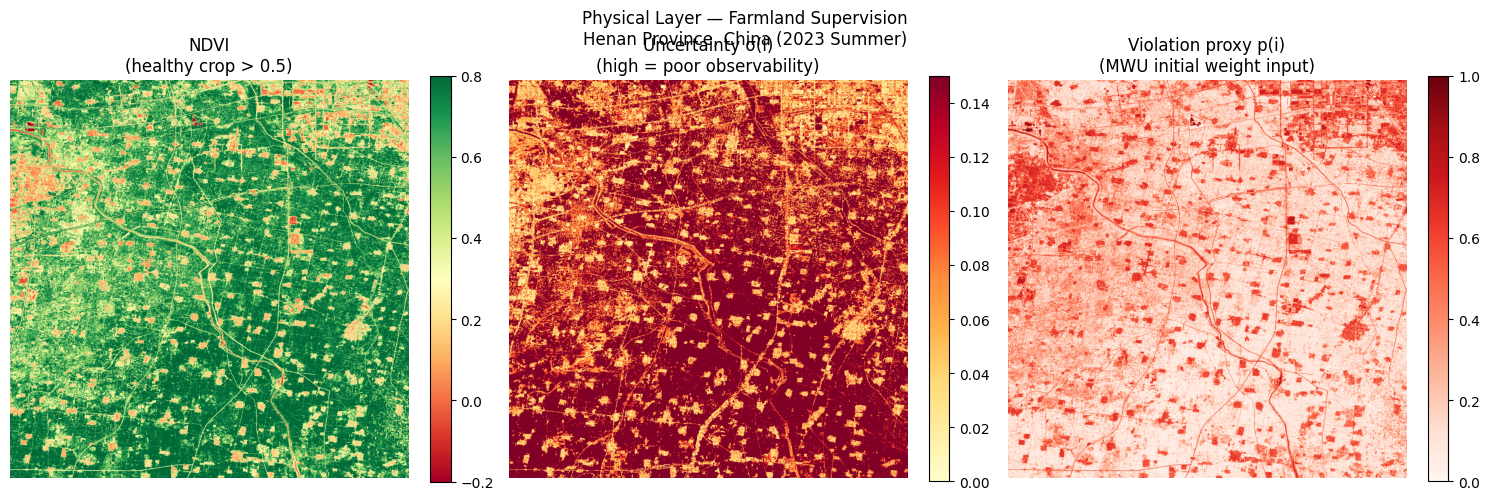

图像已保存至 report/figures/ndvi_figure1.png


: 

In [ ]:
ndvi_2d = ndvi_arr[:,:,0]

# 违规概率代理 p(i)
p_proxy = 1 - np.clip(
    (ndvi_2d - np.nanmin(ndvi_2d)) / (np.nanmax(ndvi_2d) - np.nanmin(ndvi_2d)),
    0, 1
)

# 三联图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Physical Layer — Farmland Supervision\nHenan Province, China (2023 Summer)', fontsize=12)

im0 = axes[0].imshow(ndvi_2d, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
axes[0].set_title('NDVI\n(healthy crop > 0.5)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(sigma_arr[:,:,0], cmap='YlOrRd', vmin=0, vmax=0.15)
axes[1].set_title('Uncertainty σ(i)\n(high = poor observability)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(p_proxy, cmap='Reds', vmin=0, vmax=1)
axes[2].set_title('Violation proxy p(i)\n(MWU initial weight input)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig('../report/figures/ndvi_figure1.png', dpi=150, bbox_inches='tight')
plt.show()
print("图像已保存至 report/figures/ndvi_figure1.png")